In [68]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df = \
    read_model_runs('../../data/processed/model-runs')


In [69]:
from read_model_runs import filter_complete_questions

models = ['gpt-4o-mini', 'gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3-4b-it', 'gemma-3n-e4b-it']
models = ['gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3-4b-it'] #'gemma-3n-e4b-it', 'qwen']

firacs = ['FILA_', "FIRAC", 'FIR__', 'FI___', 'FIL__', '_____', ]
firacs = ['FILA_', 'FIL__', 'FIR__', 'F____', 'FI___', '_____', 'FIRAC', 'unstructured']
question_long_df, question_wide_df, model_order, firac_order, completeness_map_df = filter_complete_questions(question_long_df, models, firacs)

print('completeness map', completeness_map_df.sort_values(by='completeness_pct'))

print('shape:', question_long_df.shape)
print('# unique questions:', question_long_df['question_id'].nunique())
print("model order:", model_order)
print("firac order:", firac_order)

#question_long_df[question_long_df.model_name == 'Qwen/Qwen2.5-7B-Instruct'][question_long_df.firac == 'unstructured']

completeness map         model_name         firac  n_questions  completeness_pct
19   gemma-3-4b-it         F____         2737          0.847368
11  gemma-3-12b-it         F____         2747          0.850464
3   gemma-3-27b-it         F____         2817          0.872136
22   gemma-3-4b-it         FIRAC         3051          0.944582
14  gemma-3-12b-it         FIRAC         3138          0.971517
10  gemma-3-12b-it         FIR__         3168          0.980805
18   gemma-3-4b-it         FIR__         3178          0.983901
16   gemma-3-4b-it         FILA_         3182          0.985139
6   gemma-3-27b-it         FIRAC         3196          0.989474
21   gemma-3-4b-it         _____         3198          0.990093
13  gemma-3-12b-it         _____         3200          0.990712
5   gemma-3-27b-it         _____         3201          0.991022
20   gemma-3-4b-it         FI___         3201          0.991022
17   gemma-3-4b-it         FIL__         3207          0.992879
12  gemma-3-12b-it     

In [70]:
question_wide_df.head()

,question_id,materia,model_name,F____,_____,unstructured,FIL__,FI___,FIR__,FILA_,FIRAC
0,oab-1.pdf-002,ÉTICA PROFISSIONAL,gemma-3-12b-it,True,False,True,True,True,True,True,True
1,oab-1.pdf-002,ÉTICA PROFISSIONAL,gemma-3-27b-it,False,False,True,True,True,True,True,True
2,oab-1.pdf-002,ÉTICA PROFISSIONAL,gemma-3-4b-it,True,True,True,True,True,True,True,True
3,oab-1.pdf-004,ÉTICA PROFISSIONAL,gemma-3-12b-it,False,False,True,True,True,True,True,True
4,oab-1.pdf-004,ÉTICA PROFISSIONAL,gemma-3-27b-it,True,True,True,True,True,True,True,True


In [71]:
import json

def count_source(row):
    rule_dict = json.loads(row["Rule"])
    return sum(1 for v in rule_dict.values() if v != [])

rule = """{"constituicao_federal": [], "codigo_penal": [] } """
row = {}
row['Rule'] = rule
assert count_source(row) == 0

rule = """{"constituicao_federal": [], "codigo_penal": [], "codigo_processo_penal": [], "clt": [], "codigo_civil": [], "codigo_processo_civil": [], "codigo_direito_consumidor": [], "estatuto_crianca_adolescente": [], "sumula_stj": [], "estatuto_oab": [{"numero": "Art. 31, \u00a71\u00ba do EAOAB", "conteudo": "O advogado possui liberdade e independ\u00eancia em sua atua\u00e7\u00e3o."}, {"numero": "Art. 6\u00ba do EAOAB", "conteudo": "N\u00e3o h\u00e1 qualquer hierarquia entre advogados, ju\u00edzes e membros do Minist\u00e9rio P\u00fablico."}], "codigo_tributario_nacional": [], "lei_federal": [{"numero": "Par\u00e1grafo \u00fanico do Art. 4\u00ba do C\u00f3digo de \u00c9tica e Disciplina da Advocacia", "conteudo": "O advogado n\u00e3o \u00e9 obrigado a atuar contra seu entendimento j\u00e1 formulado em parecer anterior."}], "doutrina": []}"""
row = {}
row['Rule'] = rule
assert count_source(row) == 2

In [72]:
import pandas as pd

# Carrega o dataframe base (um registro por questão)
exam_df = pd.read_csv("../../data/processed/oab_with_firac_portuguese_shuffle.csv")

# Calcula rule_source_count no nível da questão
exam_df["rule_source_count"] = exam_df.apply(count_source, axis=1)

exam_df[["question_id", "fact_count", "rule_count", "rule_source_count"]].to_csv("../../data/processed/question_level_stats.csv", index=False)


In [73]:
rule_source_count_table = (
    exam_df
    .groupby("rule_source_count")
    .size()
    .reset_index(name="count")
    .sort_values("rule_source_count", ascending=True)
)

rule_source_count_table

,rule_source_count,count
0,0,55
1,1,2395
2,2,670
3,3,99
4,4,9
5,5,1
6,7,1


In [74]:
import pandas as pd

def to_int_pattern(pattern):
    """
    Converts a pattern to a list of ints.
    Accepts:
      - string: "0110101"
      - list/tuple: [0,1,1,0,1]
    """
    if isinstance(pattern, str):
        return [int(c) for c in pattern]
    return list(pattern)

def errors_to_first_success(pattern):
    """
    Number of errors (0s) before the first success (1).
    If the model never succeeds, returns 0.
    """
    if 1 not in pattern:
        return 0

    count = 0
    for v in pattern:
        if v == 1:
            break
        count += 1
    return count

def successes_to_first_error(pattern):
    """
    Number of consecutive successes (1s) after the first success
    until the first error (0).

    If the model never errs after the first success, returns 0.
    If the model never succeeds, returns 0.
    """
    if 1 not in pattern:
        return 0

    started = False
    count = 0

    for v in pattern:
        if not started:
            if v == 1:
                started = True
                count = 1
        else:
            if v == 1:
                count += 1
            else:  # first error after success
                return count

    # no error occurred after success
    return 0


def compute_e2s_s2e(pattern):
    pattern = to_int_pattern(pattern)
    return pd.Series({"E2S": errors_to_first_success(pattern), "S2E": successes_to_first_error(pattern)})

assert compute_e2s_s2e("00110").to_dict() == {"E2S": 2, "S2E": 2}
assert compute_e2s_s2e("00000").to_dict()  == {"E2S": 0, "S2E": 0}
assert compute_e2s_s2e("11111").to_dict()  == {"E2S": 0, "S2E": 0}


In [75]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# Funções auxiliares
# --------------------------------------------------
def build_firac_pattern(row, firac_cols):
    return "".join(row[firac_cols].astype(int).astype(str).values)


def check_consistency_from_pattern(pattern):
    # Depois do primeiro '1', não pode haver '0'
    if "1" not in pattern:
        return True
    first_one = pattern.index("1")
    return "0" not in pattern[first_one:]


def find_consistency_breaker(pattern, firac_cols):
    """
    Retorna o nome da coluna FIRAC que quebrou a consistência
    (primeiro 0 após o primeiro 1). Se não houver quebra, retorna NaN.
    """
    if "1" not in pattern:
        return np.nan

    first_one = pattern.index("1")

    for i in range(first_one + 1, len(pattern)):
        if pattern[i] == "0":
            return firac_cols[i]

    return np.nan


# --------------------------------------------------
# Colunas FIRAC (na ordem correta)
# --------------------------------------------------
firac_cols = [c for c in firac_order if c in question_wide_df.columns]

# --------------------------------------------------
# Geração do dataframe final
# --------------------------------------------------
question_consistency_df = question_wide_df.copy()

# Padrão FIRAC (ex: 00111)
question_consistency_df["firac_response_pattern"] = question_consistency_df.apply(
    build_firac_pattern,
    axis=1,
    firac_cols=firac_cols
)

# Consistência monotônica
question_consistency_df["is_consistent"] = question_consistency_df[
    "firac_response_pattern"
].apply(check_consistency_from_pattern)

# Coluna que identifica onde quebrou
question_consistency_df["consistency_breaker"] = question_consistency_df[
    "firac_response_pattern"
].apply(find_consistency_breaker, firac_cols=firac_cols)

# Mantém apenas o necessário
question_consistency_df = question_consistency_df[
    [
        "question_id",
        "materia",
        "model_name",
        "firac_response_pattern",
        "is_consistent",
        "consistency_breaker",
    ]
]


# Apply to dataframe
question_consistency_df[["E2S", "S2E"]] = (
    question_consistency_df["firac_response_pattern"]
    .apply(compute_e2s_s2e)
)

question_consistency_df["Instability"] = (
    question_consistency_df["S2E"] /
    (question_consistency_df["E2S"] + question_consistency_df["S2E"]).replace(0, 1)
)


question_consistency_df.sort_values(by='E2S')


,question_id,materia,model_name,firac_response_pattern,is_consistent,consistency_breaker,E2S,S2E,Instability
0,oab-1.pdf-002,ÉTICA PROFISSIONAL,gemma-3-12b-it,10111111,False,_____,0,1,1.0
4458,oab-257.pdf-116,DIREITO PENAL,gemma-3-12b-it,11111111,True,NaN,0,0,0.0
4457,oab-257.pdf-115,DIREITO PENAL,gemma-3-4b-it,11111111,True,NaN,0,0,0.0
4455,oab-257.pdf-115,DIREITO PENAL,gemma-3-12b-it,11111111,True,NaN,0,0,0.0
4454,oab-257.pdf-114,DIREITO PENAL,gemma-3-4b-it,10001011,False,_____,0,1,1.0
...,...,...,...,...,...,...,...,...,...
6416,oab-322.pdf-252,DIREITO DO TRABALHO,gemma-3-4b-it,00000001,True,NaN,7,0,0.0
5648,oab-298.pdf-014,DIREITO DO TRABALHO,gemma-3-4b-it,00000001,True,NaN,7,0,0.0
6971,oab-34.pdf-342,ÉTICA PROFISSIONAL,gemma-3-4b-it,00000001,True,NaN,7,0,0.0
1592,oab-157.pdf-047,DIREITO CIVIL,gemma-3-4b-it,00000001,True,NaN,7,0,0.0


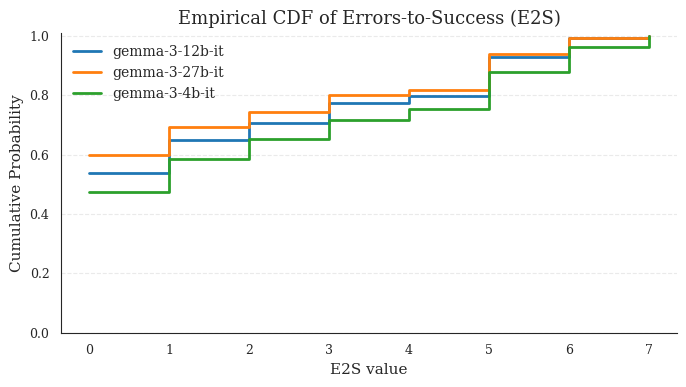

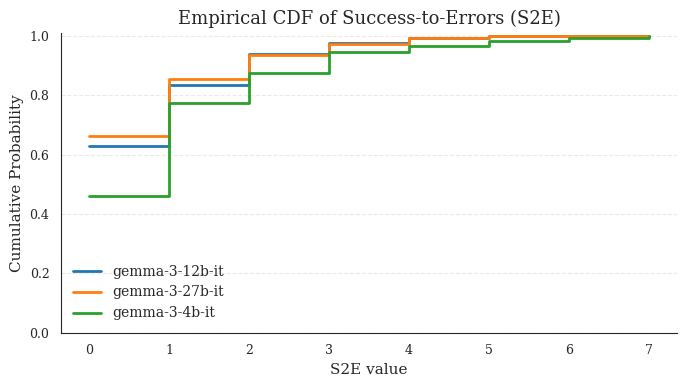

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Configuração global ACL-style
# --------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ACL_COLORS = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
]

# --------------------------------------------------
# Função para plotar CDF discreta
# --------------------------------------------------
def plot_discrete_cdf(
    df,
    value_col,
    title,
    xlabel,
):
    """
    Plota CDF empírica discreta para uma variável inteira
    (E2S ou S2E), separada por model_name.
    """

    fig, ax = plt.subplots(figsize=(7, 4))

    models = sorted(df["model_name"].unique())

    global_min = int(df[value_col].min())
    global_max = int(df[value_col].max())
    support = np.arange(global_min, global_max + 1)

    for i, model in enumerate(models):
        sub = (
            df[df["model_name"] == model][value_col]
            .dropna()
            .astype(int)
        )

        if sub.empty:
            continue

        # PMF no suporte completo
        pmf = (
            sub.value_counts(normalize=True)
            .reindex(support, fill_value=0)
            .sort_index()
        )

        cdf = pmf.cumsum()

        ax.step(
            cdf.index,
            cdf.values,
            where="post",
            linewidth=2,
            color=ACL_COLORS[i % len(ACL_COLORS)],
            label=model,
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cumulative Probability")

    ax.set_xticks(support)
    ax.set_ylim(0, 1.01)

    ax.legend(frameon=False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Plot 1 — CDF de E2S
# --------------------------------------------------
plot_discrete_cdf(
    df=question_consistency_df,
    value_col="E2S",
    title="Empirical CDF of Errors-to-Success (E2S)",
    xlabel="E2S value",
)

# --------------------------------------------------
# Plot 2 — CDF de S2E
# --------------------------------------------------
plot_discrete_cdf(
    df=question_consistency_df,
    value_col="S2E",
    title="Empirical CDF of Success-to-Errors (S2E)",
    xlabel="S2E value",
)


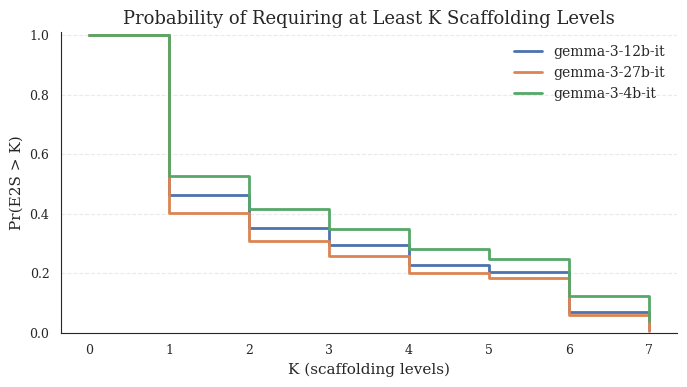

In [77]:
# =========================================================
# Probability of E2S >= K by model (ACL-style)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Global ACL-style configuration
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---------------------------------------------------------
# Plot: P(E2S >= K) by model_name
# ---------------------------------------------------------
def plot_prob_e2s_ge_k(question_consistency_df):
    """
    Plota, para cada modelo, a probabilidade
    P(E2S >= K) em função de K (função de sobrevivência discreta).
    """

    fig, ax = plt.subplots(figsize=(7, 4))

    # Modelos ordenados alfabeticamente (ou troque por média de E2S)
    models = sorted(question_consistency_df["model_name"].unique())

    # Suporte global de K
    max_k = int(question_consistency_df["E2S"].max())
    K_values = np.arange(0, max_k + 1)

    for model in models:
        e2s_values = (
            question_consistency_df
            .loc[question_consistency_df["model_name"] == model, "E2S"]
            .dropna()
            .astype(int)
        )

        if e2s_values.empty:
            continue

        # Probabilidade empírica P(E2S >= K)
        probs = [(e2s_values >= k).mean() for k in K_values]

        ax.step(
            K_values,
            probs,
            where="post",
            linewidth=2,
            label=model,
        )

    ax.set_xlabel("K (scaffolding levels)")
    ax.set_ylabel("Pr(E2S > K)")
    ax.set_title("Probability of Requiring at Least K Scaffolding Levels")

    ax.set_xticks(K_values)
    ax.set_ylim(0, 1.01)

    ax.legend(frameon=False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Run
# ---------------------------------------------------------
plot_prob_e2s_ge_k(question_consistency_df)


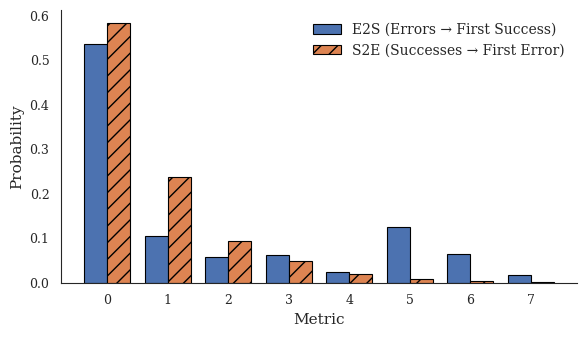

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Empirical PMFs
e2s_pmf = question_consistency_df["E2S"].value_counts(normalize=True).sort_index()
s2e_pmf = question_consistency_df["S2E"].value_counts(normalize=True).sort_index()

pmf_df = pd.DataFrame({
    "E2S": e2s_pmf,
    "S2E": s2e_pmf
}).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(6, 3.5))

x = np.arange(len(pmf_df.index))
width = 0.38

ax.bar(
    x - width/2,
    pmf_df["E2S"],
    width,
    label="E2S (Errors → First Success)",
    edgecolor="black",
    linewidth=0.8
)

ax.bar(
    x + width/2,
    pmf_df["S2E"],
    width,
    label="S2E (Successes → First Error)",
    edgecolor="black",
    linewidth=0.8,
    hatch="//"
)

ax.set_xlabel("Metric")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(pmf_df.index)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Estatísticas básicas por modelo
# --------------------------------------------------
stats_by_model = (
    question_consistency_df
    .groupby("model_name")
    .agg({
        "E2S": ["mean", "median", "min", "max", "std", "count"],
        "S2E": ["mean", "median", "min", "max", "std", "count"],
       # "Instability": ["mean", "median", "min", "max", "std"]
    })
    .reset_index()
)

# --------------------------------------------------
# Flatten column names
# --------------------------------------------------
stats_by_model.columns = [
    "model_name" if col[0] == "model_name" else f"{col[0]}_{col[1]}"
    for col in stats_by_model.columns
]

# --------------------------------------------------
# Intervalo de Confiança 95% da média
# --------------------------------------------------
Z_95 = 1.96

# --- E2S ---
stats_by_model["E2S_ci95_low"] = (
    stats_by_model["E2S_mean"]
    - Z_95 * stats_by_model["E2S_std"] / np.sqrt(stats_by_model["E2S_count"])
)

stats_by_model["E2S_ci95_high"] = (
    stats_by_model["E2S_mean"]
    + Z_95 * stats_by_model["E2S_std"] / np.sqrt(stats_by_model["E2S_count"])
)


# --- S2E ---
stats_by_model["S2E_ci95_low"] = (
    stats_by_model["S2E_mean"]
    - Z_95 * stats_by_model["S2E_std"] / np.sqrt(stats_by_model["S2E_count"])
)

stats_by_model["S2E_ci95_high"] = (
    stats_by_model["S2E_mean"]
    + Z_95 * stats_by_model["S2E_std"] / np.sqrt(stats_by_model["S2E_count"])
)


# --------------------------------------------------
# Ordenar por E2S médio (↑ = melhor)
# --------------------------------------------------
stats_by_model = stats_by_model.sort_values(
    by="E2S_mean",
    ascending=True
)

stats_by_model


,model_name,E2S_mean,E2S_median,E2S_min,E2S_max,E2S_std,E2S_count,S2E_mean,S2E_median,S2E_min,S2E_max,S2E_std,S2E_count,E2S_ci95_low,E2S_ci95_high,S2E_ci95_low,S2E_ci95_high
1,gemma-3-27b-it,1.415443,0.0,0,7,2.097184,2655,0.586064,0.0,0,6,1.018681,2655,1.335669,1.495216,0.547315,0.624813
0,gemma-3-12b-it,1.613183,0.0,0,7,2.163245,2655,0.633898,0.0,0,6,1.019802,2655,1.530896,1.695469,0.595107,0.672690
2,gemma-3-4b-it,1.981544,1.0,0,7,2.379112,2655,1.005650,1.0,0,7,1.354458,2655,1.891046,2.072042,0.954128,1.057171


: 

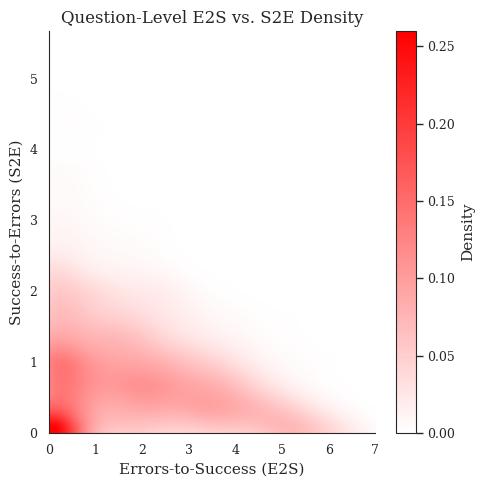

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.stats import gaussian_kde

# --------------------------------------------------
# KDE (same aggregation as before)
# --------------------------------------------------
agg_df = (
    question_consistency_df
    .groupby("question_id", as_index=False)
    .agg(
        E2S_mean=("E2S", "mean"),
        S2E_mean=("S2E", "mean"),
    )
)

x = agg_df["E2S_mean"].values
y = agg_df["S2E_mean"].values

xy = np.vstack([x, y])
kde = gaussian_kde(xy)

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
grid = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid).reshape(xx.shape)

# --------------------------------------------------
# Mask near-zero density → white
# --------------------------------------------------
threshold = np.percentile(zz, 5)
zz_masked = np.ma.masked_where(zz < threshold, zz)

# --------------------------------------------------
# White → red colormap
# --------------------------------------------------
cmap = colors.LinearSegmentedColormap.from_list(
    "white_red",
    ["#ffffff", "#ff0000"]
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(5, 5))

plt.imshow(
    zz_masked.T,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="auto",
    cmap=cmap
)

plt.colorbar(label="Density")

plt.xlabel("Errors-to-Success (E2S)", fontsize=11)
plt.ylabel("Success-to-Errors (S2E)", fontsize=11)
plt.title("Question-Level E2S vs. S2E Density", fontsize=12)

plt.tight_layout()
plt.show()


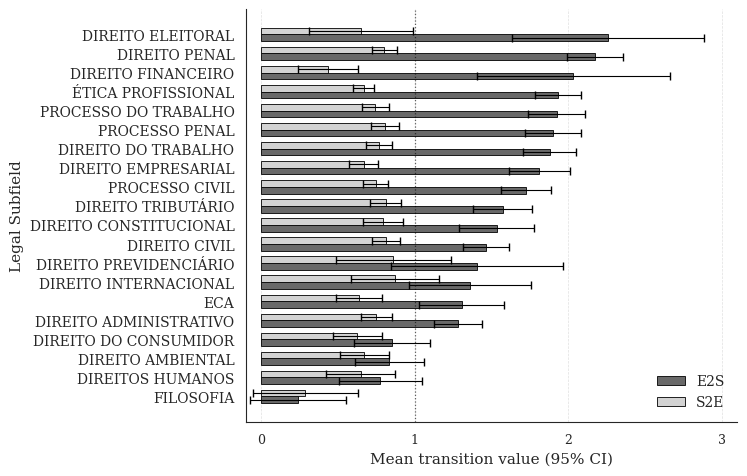

In [81]:
# ============================================================
# Barras horizontais ACL-style (FINAL CLEAN)
# E2S e S2E médios por matéria + IC 95%
# Ordenado por E2S_mean
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Agregação: média, std, n e IC 95%
# ------------------------------------------------------------
summary_df = (
    question_consistency_df
    .groupby("materia")
    .agg(
        E2S_mean=("E2S", "mean"),
        E2S_std=("E2S", "std"),
        S2E_mean=("S2E", "mean"),
        S2E_std=("S2E", "std"),
        n=("E2S", "count")
    )
    .reset_index()
    .sort_values("E2S_mean")
)

summary_df["E2S_ci95"] = 1.96 * summary_df["E2S_std"] / np.sqrt(summary_df["n"])
summary_df["S2E_ci95"] = 1.96 * summary_df["S2E_std"] / np.sqrt(summary_df["n"])


# ------------------------------------------------------------
# 2. Plot ACL-style
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 4.9))

y = np.arange(len(summary_df))
bar_height = 0.35

# cores neutras ACL
e2s_color = "dimgray"
s2e_color = "lightgray"

# E2S
ax.barh(
    y - bar_height / 2,
    summary_df["E2S_mean"],
    xerr=summary_df["E2S_ci95"],
    height=bar_height,
    color=e2s_color,
    edgecolor="black",
    linewidth=0.6,
    error_kw=dict(ecolor="black", lw=0.8, capsize=3),
    label="E2S"
)

# S2E
ax.barh(
    y + bar_height / 2,
    summary_df["S2E_mean"],
    xerr=summary_df["S2E_ci95"],
    height=bar_height,
    color=s2e_color,
    edgecolor="black",
    linewidth=0.6,
    error_kw=dict(ecolor="black", lw=0.8, capsize=3),
    label="S2E"
)


# ------------------------------------------------------------
# 3. Eixos e marcações
# ------------------------------------------------------------
ax.set_yticks(y)
ax.set_yticklabels(summary_df["materia"], fontsize=10)

ax.set_xlabel("Mean transition value (95% CI)", fontsize=11)
ax.set_ylabel("Legal Subfield", fontsize=11)

# eixo discreto explícito
ax.set_xlim(-0.1, 3.1)
ax.set_xticks([0, 1, 2, 3])

# linha de referência conceitual
ax.axvline(
    1,
    linestyle=":",
    linewidth=0.9,
    color="black",
    alpha=0.6
)


# ------------------------------------------------------------
# 4. Estilo ACL
# ------------------------------------------------------------
ax.legend(frameon=False, fontsize=10, loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.5,
    alpha=0.6
)

plt.tight_layout()
plt.savefig(
    "../../reports/mean_e2s_s2e_by_materia_ci95.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


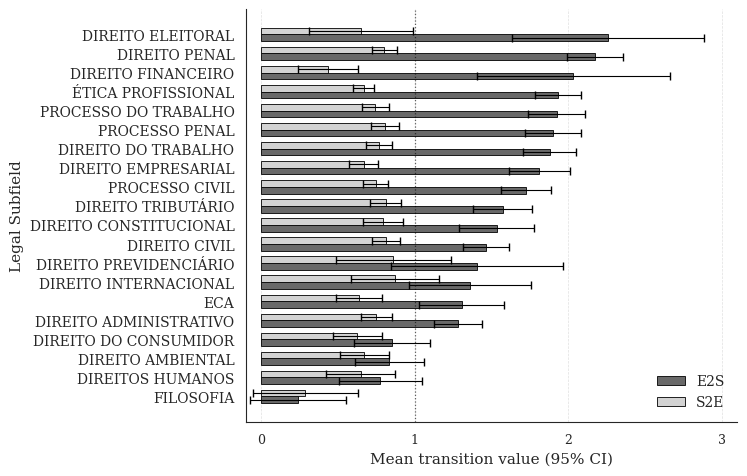

In [82]:
# ============================================================
# Barras horizontais ACL-style (FINAL CLEAN)
# E2S e S2E médios por matéria + IC 95%
# Ordenado por E2S_mean
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Agregação: média, std, n e IC 95%
# ------------------------------------------------------------
summary_df = (
    question_consistency_df
    .groupby("materia")
    .agg(
        E2S_mean=("E2S", "mean"),
        E2S_std=("E2S", "std"),
        S2E_mean=("S2E", "mean"),
        S2E_std=("S2E", "std"),
        n=("E2S", "count")
    )
    .reset_index()
    .sort_values("E2S_mean")
)

summary_df["E2S_ci95"] = 1.96 * summary_df["E2S_std"] / np.sqrt(summary_df["n"])
summary_df["S2E_ci95"] = 1.96 * summary_df["S2E_std"] / np.sqrt(summary_df["n"])


# ------------------------------------------------------------
# 2. Plot ACL-style
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 4.9))

y = np.arange(len(summary_df))
bar_height = 0.35

# cores neutras ACL
e2s_color = "dimgray"
s2e_color = "lightgray"

# E2S
ax.barh(
    y - bar_height / 2,
    summary_df["E2S_mean"],
    xerr=summary_df["E2S_ci95"],
    height=bar_height,
    color=e2s_color,
    edgecolor="black",
    linewidth=0.6,
    error_kw=dict(ecolor="black", lw=0.8, capsize=3),
    label="E2S"
)

# S2E
ax.barh(
    y + bar_height / 2,
    summary_df["S2E_mean"],
    xerr=summary_df["S2E_ci95"],
    height=bar_height,
    color=s2e_color,
    edgecolor="black",
    linewidth=0.6,
    error_kw=dict(ecolor="black", lw=0.8, capsize=3),
    label="S2E"
)


# ------------------------------------------------------------
# 3. Eixos e marcações
# ------------------------------------------------------------
ax.set_yticks(y)
ax.set_yticklabels(summary_df["materia"], fontsize=10)

ax.set_xlabel("Mean transition value (95% CI)", fontsize=11)
ax.set_ylabel("Legal Subfield", fontsize=11)

# eixo discreto explícito
ax.set_xlim(-0.1, 3.1)
ax.set_xticks([0, 1, 2, 3])

# linha de referência conceitual
ax.axvline(
    1,
    linestyle=":",
    linewidth=0.9,
    color="black",
    alpha=0.6
)


# ------------------------------------------------------------
# 4. Estilo ACL
# ------------------------------------------------------------
ax.legend(frameon=False, fontsize=10, loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.5,
    alpha=0.6
)

plt.tight_layout()
plt.savefig(
    "mean_e2s_s2e_by_materia_ci95_acl_FINAL_CLEAN.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


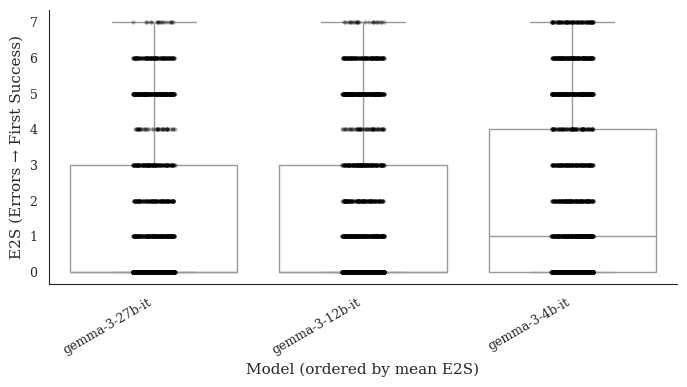

In [83]:
# Order models by mean E2S (ascending)
model_order_e2s = (
    question_consistency_df
    .groupby("model_name")["E2S"]
    .mean()
    .sort_values()
    .index
)

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=question_consistency_df,
    x="model_name",
    y="E2S",
    order=model_order_e2s,
    color="white",
    linewidth=1
)

sns.stripplot(
    data=question_consistency_df,
    x="model_name",
    y="E2S",
    order=model_order_e2s,
    color="black",
    alpha=0.3,
    size=3
)

plt.xlabel("Model (ordered by mean E2S)")
plt.ylabel("E2S (Errors → First Success)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [84]:
question_consistency_df['question_id'].nunique()

2655

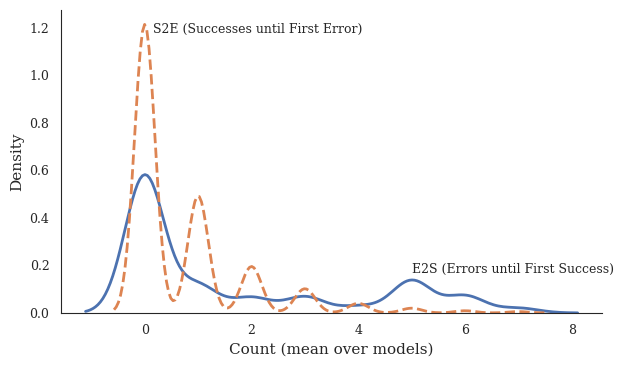

In [85]:
# --------------------------------------------------
# 3. KDE plot with inline labels
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 3.8))  # ACL-friendly aspect ratio

sns.kdeplot(
    data=question_consistency_df,
    x="E2S",
    linewidth=2,
    ax=ax
)

sns.kdeplot(
    data=question_consistency_df,
    x="S2E",
    linewidth=2,
    linestyle="--",
    ax=ax
)

# --------------------------------------------------
# 4. Inline labels near the curves
# --------------------------------------------------
lines = ax.get_lines()

for line, label, x_offset, y_offset in zip(
    lines,
    ["E2S (Errors until First Success)", "S2E (Successes until First Error)"],
    [5, 0.15],   # x offsets (tune if needed)
    [-0.4, -0.02], # y offsets
):
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    idx = y_data.argmax()
    x_peak = x_data[idx]
    y_peak = y_data[idx]

    ax.text(
        x_peak + x_offset,
        y_peak + y_offset,
        label,
        fontsize=9,
        ha="left",
        va="center"
    )

ax.set_xlabel("Count (mean over models)")
ax.set_ylabel("Density")

# remove top/right spines (ACL style)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# --------------------------------------------------
# 5. Save figure
# --------------------------------------------------
output_path = "../../reports/kde_e2s_s2e_by_question.pdf"
plt.tight_layout()
plt.savefig(output_path, format="pdf", bbox_inches="tight")

plt.show()


plt.close()


In [86]:
import pandas as pd

# --------------------------------------------------
# Filtra apenas casos onde houve quebra de consistência
# --------------------------------------------------
breaker_df = question_consistency_df.dropna(subset=["consistency_breaker"])

# --------------------------------------------------
# Tabela de contagem
# --------------------------------------------------
count_df = (
    breaker_df
    .groupby(["model_name", "consistency_breaker"])
    .size()
    .reset_index(name="count")
)

# --------------------------------------------------
# Pivot + normalização por linha (soma = 100%)
# --------------------------------------------------
question_consistency_breaker_df = (
    count_df
    .pivot(index="model_name", columns="consistency_breaker", values="count")
    .fillna(0)
)

question_consistency_breaker_df = (
    question_consistency_breaker_df
    .div(question_consistency_breaker_df.sum(axis=1), axis=0)
    .mul(100)
)

# --------------------------------------------------
# Opcional: ordena colunas na ordem FIRAC
# --------------------------------------------------
ordered_cols = [c for c in firac_cols if c in question_consistency_breaker_df.columns]
question_consistency_breaker_df = question_consistency_breaker_df[ordered_cols]

question_consistency_breaker_df


consistency_breaker,_____,unstructured,FIL__,FI___,FIR__,FILA_,FIRAC
model_name,,,,,,,
gemma-3-12b-it,24.491870,26.524390,23.170732,16.565041,4.674797,2.540650,2.032520
gemma-3-27b-it,27.000000,26.777778,20.888889,16.777778,4.777778,1.777778,2.000000
gemma-3-4b-it,23.303009,19.244227,19.874038,12.946116,6.508048,10.566830,7.557733


In [87]:
import pandas as pd

# --------------------------------------------------
# 1) Média de acurácia por question_id × firac
# --------------------------------------------------
mean_by_firac = (
    question_long_df
    .groupby(["question_id", "firac"], as_index=False)
    .agg(
        mean_accuracy_firac=("is_correct", "mean"),
        n_obs_firac=("is_correct", "size")
    )
)

# --------------------------------------------------
# 2) Média geral (todos os FIRACs) por question_id
# --------------------------------------------------
mean_overall = (
    question_long_df
    .groupby("question_id", as_index=False)
    .agg(
        mean_accuracy_all=("is_correct", "mean"),
        n_obs_all=("is_correct", "size")
    )
)

# --------------------------------------------------
# 3) Merge
# --------------------------------------------------
df = mean_by_firac.merge(
    mean_overall,
    on="question_id",
    how="left"
)

# --------------------------------------------------
# 4) Média dos "outros" FIRACs
#    (remove contribuição do próprio nível)
# --------------------------------------------------
df["mean_accuracy_other_firac"] = (
    (df["mean_accuracy_all"] * df["n_obs_all"]
     - df["mean_accuracy_firac"] * df["n_obs_firac"])
    / (df["n_obs_all"] - df["n_obs_firac"])
)

# --------------------------------------------------
# 5) Diferença (delta FIRAC)
# --------------------------------------------------
df["delta_accuracy_firac"] = (
    df["mean_accuracy_firac"]
    - df["mean_accuracy_other_firac"]
)

# Resultado final
delta_firac_df = df[
    [
        "question_id",
        "firac",
        "mean_accuracy_firac",
        "mean_accuracy_other_firac",
        "delta_accuracy_firac",
    ]
]

import pandas as pd

delta_firac_wide_df = (
    delta_firac_df
    .pivot(
        index="question_id",
        columns="firac",
        values="delta_accuracy_firac"
    )
    .reset_index()
)

delta_firac_wide_df.to_csv("../../data/processed/delta_firac.csv", index=False)

delta_firac_wide_df.head()

firac,question_id,FILA_,FIL__,FIRAC,FIR__,FI___,F____,_____,unstructured
0,oab-1.pdf-002,0.142857,0.142857,0.142857,0.142857,0.142857,-0.238095,-0.619048,0.142857
1,oab-1.pdf-004,0.285714,-0.095238,0.285714,0.285714,-0.095238,-0.476190,-0.476190,0.285714
2,oab-1.pdf-006,0.142857,-0.238095,0.142857,0.142857,-0.238095,-0.238095,0.142857,0.142857
3,oab-1.pdf-008,0.000000,0.000000,0.380952,0.380952,0.380952,-0.761905,-0.380952,0.000000
4,oab-1.pdf-009,0.190476,0.190476,0.190476,0.190476,-0.190476,-0.571429,-0.190476,0.190476
